<a href="https://colab.research.google.com/github/eternitvy/PCVK_26/blob/main/Jobsheet2/JS02_TUGAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Tampilan cv2_imshow ---


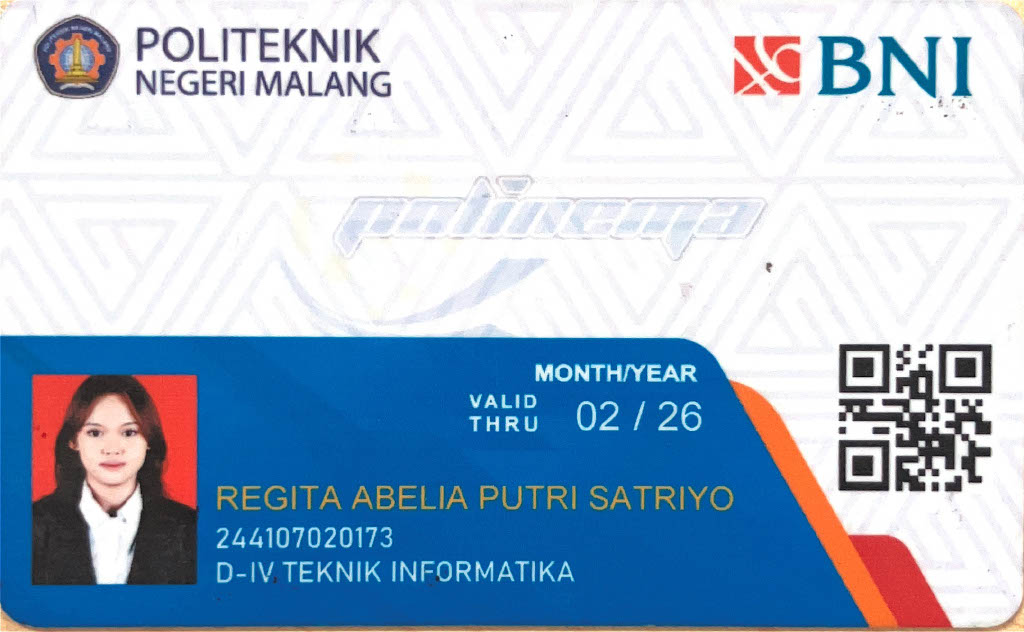

--- Tampilan plt.imshow ---


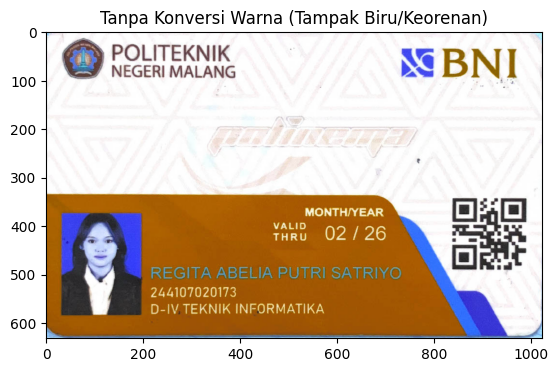

Nilai piksel pada (100, 100) dalam BGR: [247 244 246]
Penyebab: OpenCV menganggap BGR = [Blue: 247, Green: 244, Red: 246].
Matplotlib menampilkan nilai BGR tersebut sebagai RGB = [Red: 247, Green: 244, Blue: 246].


In [21]:
# Soal 1
import cv2 as cv
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Membaca citra menggunakan OpenCV
img = cv2.imread('KTMlama.jpg')

# Tampilkan dengan cv2_imshow (format BGR dieksekusi dengan benar)
print("--- Tampilan cv2_imshow ---")
cv2_imshow(img)

# Tampilkan dengan plt.imshow (format BGR dianggap RGB)
print("--- Tampilan plt.imshow ---")
plt.imshow(img)
plt.title("Tanpa Konversi Warna (Tampak Biru/Keorenan)")
plt.show()

# Bukti nilai piksel pada koordinat (y=100, x=100)
pixel_val = img[100, 100]
print(f"Nilai piksel pada (100, 100) dalam BGR: {pixel_val}")
print(f"Penyebab: OpenCV menganggap BGR = [Blue: {pixel_val[0]}, Green: {pixel_val[1]}, Red: {pixel_val[2]}].")
print(f"Matplotlib menampilkan nilai BGR tersebut sebagai RGB = [Red: {pixel_val[0]}, Green: {pixel_val[1]}, Blue: {pixel_val[2]}].")

In [22]:
# Soal 2
import numpy as np

img_int16 = np.zeros((530, 530, 3), dtype=np.int16)
img_int32 = np.zeros((530, 530, 3), dtype=np.int32)

print(f"Kanvas 1 -> dtype: {img_int16.dtype}, min: {img_int16.min()}, max: {img_int16.max()}, nbytes: {img_int16.nbytes} bytes")
print(f"Kanvas 2 -> dtype: {img_int32.dtype}, min: {img_int32.min()}, max: {img_int32.max()}, nbytes: {img_int32.nbytes} bytes")

Kanvas 1 -> dtype: int16, min: 0, max: 0, nbytes: 1685400 bytes
Kanvas 2 -> dtype: int32, min: 0, max: 0, nbytes: 3370800 bytes


Saving KTMlama.jpg to KTMlama (1).jpg


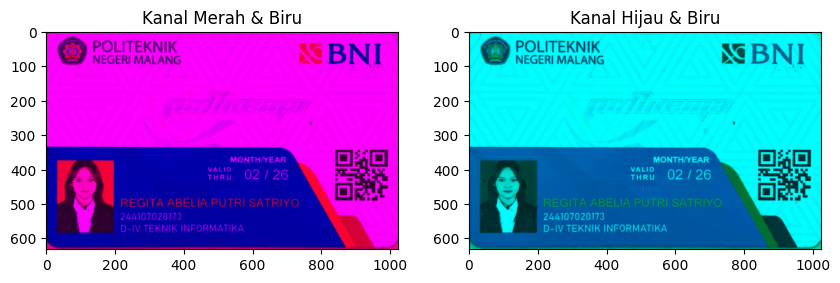

In [23]:
# TUGAS PENERAPAN
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

from google.colab import files
uploaded = files.upload()
img = cv.imread('KTMlama.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)



# 2. Menyalin array agar manipulasi tidak mengubah citra asli
img_rb = img_rgb.copy()
img_gb = img_rgb.copy()

# 3. Operasi pengirisan (slicing) untuk menolkan (0) kanal warna yang tidak dipakai
img_rb[:, :, 1] = 0 # Nol-kan kanal Hijau untuk kombinasi Merah-Biru
img_gb[:, :, 0] = 0 # Nol-kan kanal Merah untuk kombinasi Hijau-Biru

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rb)
plt.title('Kanal Merah & Biru')

plt.subplot(1, 2, 2)
plt.imshow(img_gb)
plt.title('Kanal Hijau & Biru')

plt.show()

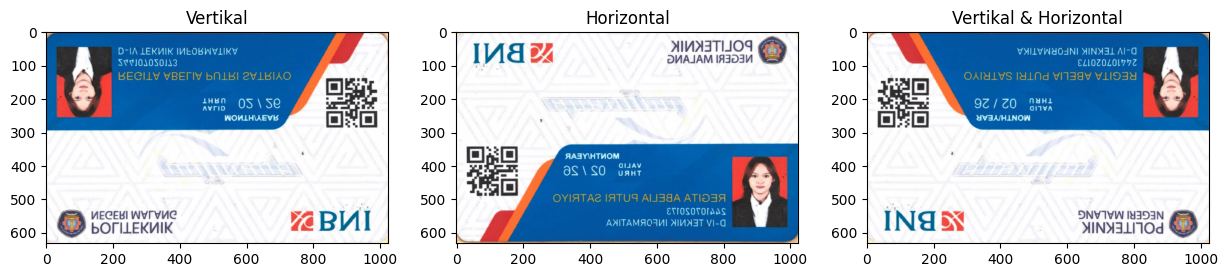

In [24]:
# TUGAS PENERAPAN
img_vertikal = cv.flip(img_rgb, 0)
img_horizontal = cv.flip(img_rgb, 1)
img_keduanya = cv.flip(img_rgb, -1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_vertikal)
plt.title('Vertikal')

plt.subplot(1, 3, 2)
plt.imshow(img_horizontal)
plt.title('Horizontal')

plt.subplot(1, 3, 3)
plt.imshow(img_keduanya)
plt.title('Vertikal & Horizontal')

plt.show()

In [25]:
uploaded = files.upload()
img = cv.imread('foto_pcvk.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)


Saving foto_pcvk.jpg to foto_pcvk.jpg


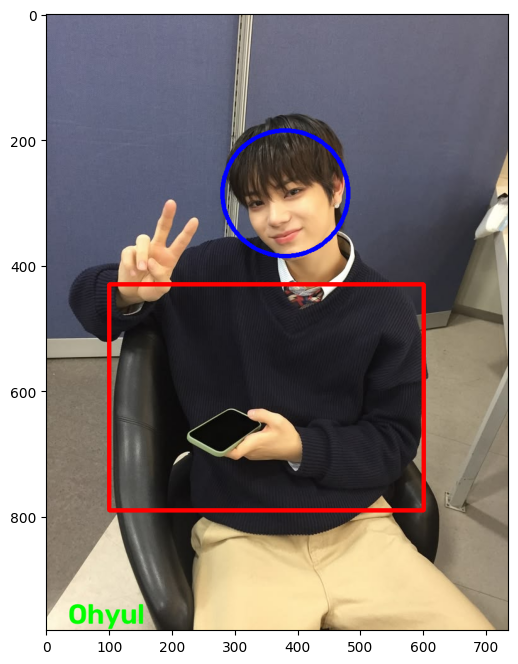

In [26]:
# TUGAS PENERAPAN

# 1. Salin citra asli dan dapatkan ukuran dimensinya
img_draw = img_rgb.copy()
h, w = img_draw.shape[:2]

# 2. Gambar persegi pada area badan
cv.rectangle(img_draw, pt1=(100, 430), pt2=(600, 790), color=(255, 0, 0), thickness=5)

# 3. Gambar lingkaran pada area wajah
cv.circle(img_draw, center=(380, 285), radius=100, color=(0, 0, 255), thickness=5)

# 4. teks
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(img_draw, text='Ohyul', org=(35, h - 10), fontFace=font, fontScale=1.5, color=(0, 255, 0), thickness=3, lineType=cv.LINE_AA)

# 5. Tampilkan hasilnya
plt.figure(figsize=(8,8))
plt.imshow(img_draw)
plt.show()

In [29]:
# TUGAS ANALISIS

# 1. Membaca Citra Grayscale
img_gray = cv2.imread('KTMlama.jpg', cv2.IMREAD_GRAYSCALE)
h, w = img_gray.shape

# 2. Hitung Rata-Rata Awal
mean_awal = np.mean(img_gray)

# 3. Downscale 50%
img_small = cv2.resize(img_gray, (w // 2, h // 2), interpolation=cv2.INTER_AREA)

# 4. Upscale Kembali ke Ukuran Asli (100%)
img_restored = cv2.resize(img_small, (w, h), interpolation=cv2.INTER_CUBIC)

# 5. Hitung Rata-Rata Akhir dan MSE
mean_akhir = np.mean(img_restored)
mse_error = np.mean((img_gray.astype("float") - img_restored.astype("float")) ** 2)

print("=== HASIL EKSPERIMEN ANALISIS CITRA ===")
print(f"Resolusi Awal            : {w}x{h}")
print(f"Rata-rata Intensitas Awal : {mean_awal:.4f}")
print(f"Rata-rata Intensitas Akhir: {mean_akhir:.4f}")
print(f"Selisih Rata-rata Perubahan: {abs(mean_awal - mean_akhir):.4f}")
print(f"Mean Squared Error (MSE) : {mse_error:.4f}")

=== HASIL EKSPERIMEN ANALISIS CITRA ===
Resolusi Awal            : 1024x632
Rata-rata Intensitas Awal : 179.8892
Rata-rata Intensitas Akhir: 179.9628
Selisih Rata-rata Perubahan: 0.0736
Mean Squared Error (MSE) : 27.5535


**STUDI KASUS 1**

Silakan unggah foto (bisa unggah foto lanskap dan potret sekaligus):


Saving foto_pcvk.jpg to foto_pcvk (1).jpg
Saving Lanskap.jpg to Lanskap.jpg


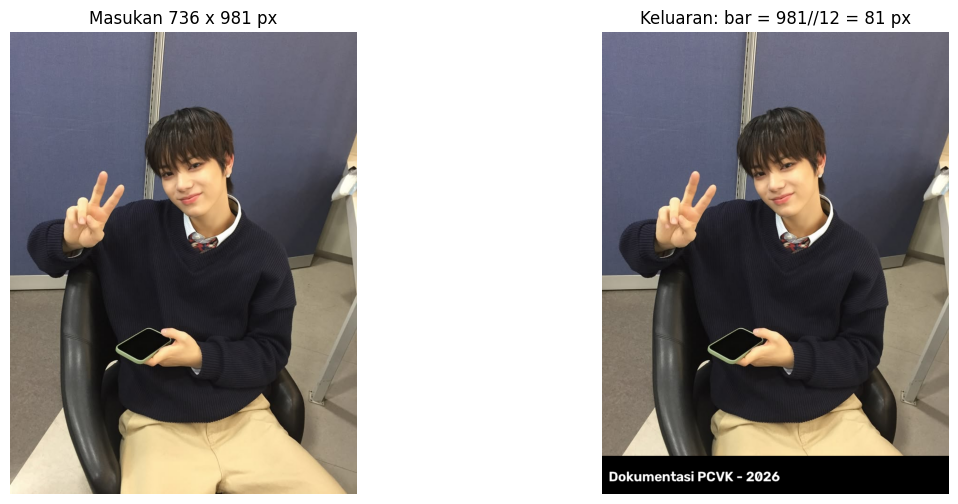

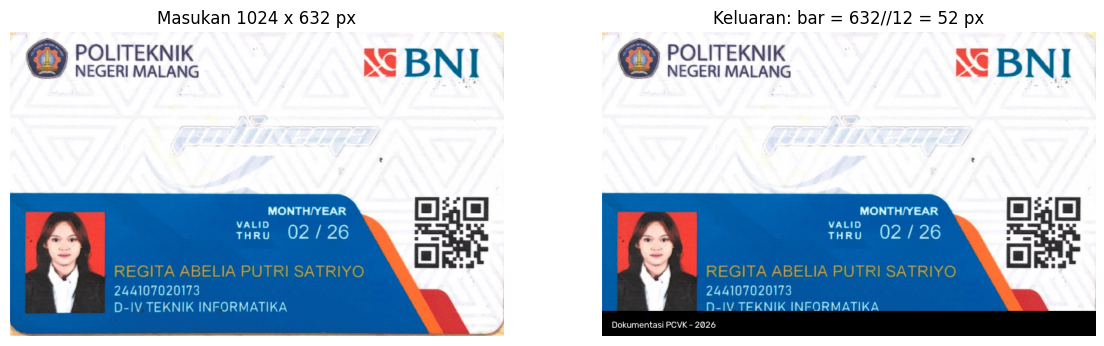

In [27]:
print("Silakan unggah foto (bisa unggah foto lanskap dan potret sekaligus):")
uploaded = files.upload()

for filename in uploaded.keys():
    # 1. Membaca citra dan konversi ke RGB
    img_asli = cv.imread(filename)
    img_asli_rgb = cv.cvtColor(img_asli, cv.COLOR_BGR2RGB)

    # Salin citra asli untuk dimanipulasi
    img_hasil = img_asli_rgb.copy()

    # 2. Mendapatkan dimensi citra
    h, w = img_hasil.shape[:2]

    # 3. Perhitungan proporsional adaptif sesuai instruksi
    tinggi_bar = h // 12
    skala_font = h / 1000.0
    tebal_teks = h // 400
    if tebal_teks < 1:
        tebal_teks = 1

    # 4. Menggambar latar bar hitam solid di area bawah
    cv.rectangle(img_hasil, pt1=(0, h - tinggi_bar), pt2=(w, h), color=(0, 0, 0), thickness=-1)

    # 5. Menambahkan teks
    font = cv.FONT_HERSHEY_SIMPLEX
    pos_x = int(w * 0.02) # Jarak dari kiri sedikit diberi margin
    pos_y = h - (tinggi_bar // 3)
    cv.putText(img_hasil, text="Dokumentasi PCVK - 2026", org=(pos_x, pos_y),
               fontFace=font, fontScale=skala_font, color=(255, 255, 255),
               thickness=tebal_teks, lineType=cv.LINE_AA)

    # 6. Menampilkan perbandingan secara berdampingan dengan subplot
    plt.figure(figsize=(14, 6))

    # Subplot Kiri: Citra Masukan
    plt.subplot(1, 2, 1)
    plt.imshow(img_asli_rgb)
    plt.title(f'Masukan {w} x {h} px')
    plt.axis('off') # Menghilangkan angka sumbu (axis) agar mirip dengan gambar referensi

    # Subplot Kanan: Citra Keluaran
    plt.subplot(1, 2, 2)
    plt.imshow(img_hasil)
    plt.title(f'Keluaran: bar = {h}//12 = {tinggi_bar} px')
    plt.axis('off')

    # Tampilkan plot per gambar
    plt.show()

**STUDI KASUS 2**

Saving Potret.jpg to Potret.jpg


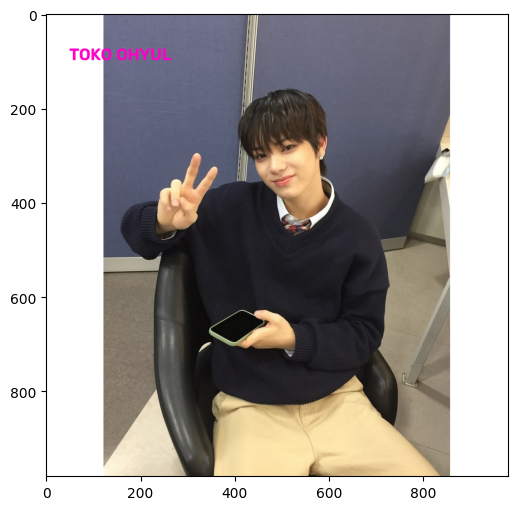

In [28]:
uploaded = files.upload()

for filename in uploaded.keys():
    img_kasus2 = cv.imread(filename)
    img_kasus2_rgb = cv.cvtColor(img_kasus2, cv.COLOR_BGR2RGB)

    # 2. Mendapatkan ukuran tinggi dan lebar citra secara aman dari atribut shape
    h, w = img_kasus2_rgb.shape[:2]

    # 3. Menentukan sisi maksimal agar menjadi rasio persegi (1:1)
    if h > w:
        sisi_max = h
    else:
        sisi_max = w

    # 4. Membuat kanvas persegi dengan latar putih (nilai 255) menggunakan NumPy
    kanvas_persegi = np.full((sisi_max, sisi_max, 3), 255, dtype=np.uint8)

    # 5. Menghitung posisi offset agar citra berada di tengah kanvas
    offset_y = (sisi_max - h) // 2
    offset_x = (sisi_max - w) // 2

    # 6. Menempatkan citra ke dalam kanvas persegi menggunakan pengirisan (slicing) NumPy
    kanvas_persegi[offset_y:offset_y+h, offset_x:offset_x+w] = img_kasus2_rgb

    # 7. Menambahkan teks/logo toko menggunakan fungsi putText OpenCV yang adaptif
    skala_font = sisi_max / 800.0
    tebal_teks = sisi_max // 400
    if tebal_teks < 1:
        tebal_teks = 1

    font = cv.FONT_HERSHEY_SIMPLEX
    cv.putText(kanvas_persegi, text='TOKO OHYUL', org=(int(sisi_max * 0.05), int(sisi_max * 0.1)),
               fontFace=font, fontScale=skala_font, color=(255, 0, 200),
               thickness=tebal_teks, lineType=cv.LINE_AA)

    # 8. Menampilkan citra hasil menggunakan Matplotlib plt.imshow sesuai modul
    plt.figure(figsize=(6, 6))
    plt.imshow(kanvas_persegi)
    plt.show()